In [1]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import pink

from sparcl.client import SparclClient
from lmfit.models import Model, LinearModel, PolynomialModel
from lmfit.models import GaussianModel, LorentzianModel
from astropy.convolution import convolve, Gaussian1DKernel
from astropy import units as u
from scipy.integrate import trapezoid
from specutils import Spectrum1D, SpectralRegion
from specutils.fitting import fit_lines, fit_generic_continuum

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"legend.frameon":False})

### data loading

In [2]:
path = "data/query_results_from_dr1_agnqso.csv"

results = pd.read_csv(path,index_col=0)
results

,targetid,z,zerr,zwarn,civ_1549_flux,civ_1549_flux_ivar,civ_1549_sigma,flux_w3,flux_ivar_w3,spectype,survey
0,39633221419275546,2.440016,0.000635,0,208.402770,0.020173,3418.65480,19.313930,0.002920,QSO,main
1,39633217375964718,2.117797,0.000656,0,110.908840,0.012570,3048.58330,8.500388,0.003168,QSO,main
2,39633217375961604,2.189153,0.000326,0,43.242090,0.070611,597.65550,13.696554,0.002910,QSO,main
3,39633221419271454,2.320267,0.000859,0,233.598630,0.013143,4489.66750,2.761181,0.003186,QSO,main
4,39633221419271778,2.218200,0.000769,0,100.735690,0.016395,3171.20200,-81.434450,0.003246,QSO,main
...,...,...,...,...,...,...,...,...,...,...,...
532230,39633158747983618,2.327047,0.000193,0,210.939650,0.032602,1647.80700,-55.228440,0.002901,QSO,main
532231,39633158747985967,2.392584,0.000163,0,888.902300,0.013076,2714.59160,57.523330,0.003068,QSO,main
532232,39633158747983695,2.770790,0.000210,0,59.914715,0.108804,818.77783,-5.375127,0.002865,QSO,main
532233,39633158752174909,2.109610,0.000269,0,352.783540,0.016585,1963.30530,18.227741,0.002832,QSO,main


In [3]:
# client = SparclClient()

# idxs = results["targetid"].to_list()

# idxs = [int(x) for x in idxs]

# output_fields = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary','survey', 'data_release', 'targetid', 'redshift_warning', 'desi_target']

# # spectra = client.retrieve_by_specid(specid_list=idxs[:50], include=output_fields,dataset_list=["DESI-DR1"])

# # spectra_df = pd.DataFrame(spectra.data[1:])
# # spectra_df

In [4]:
path = "data/line_measurement_sample.json"
# spectra_df.to_json(path)
spectra_df = pd.read_json(path)

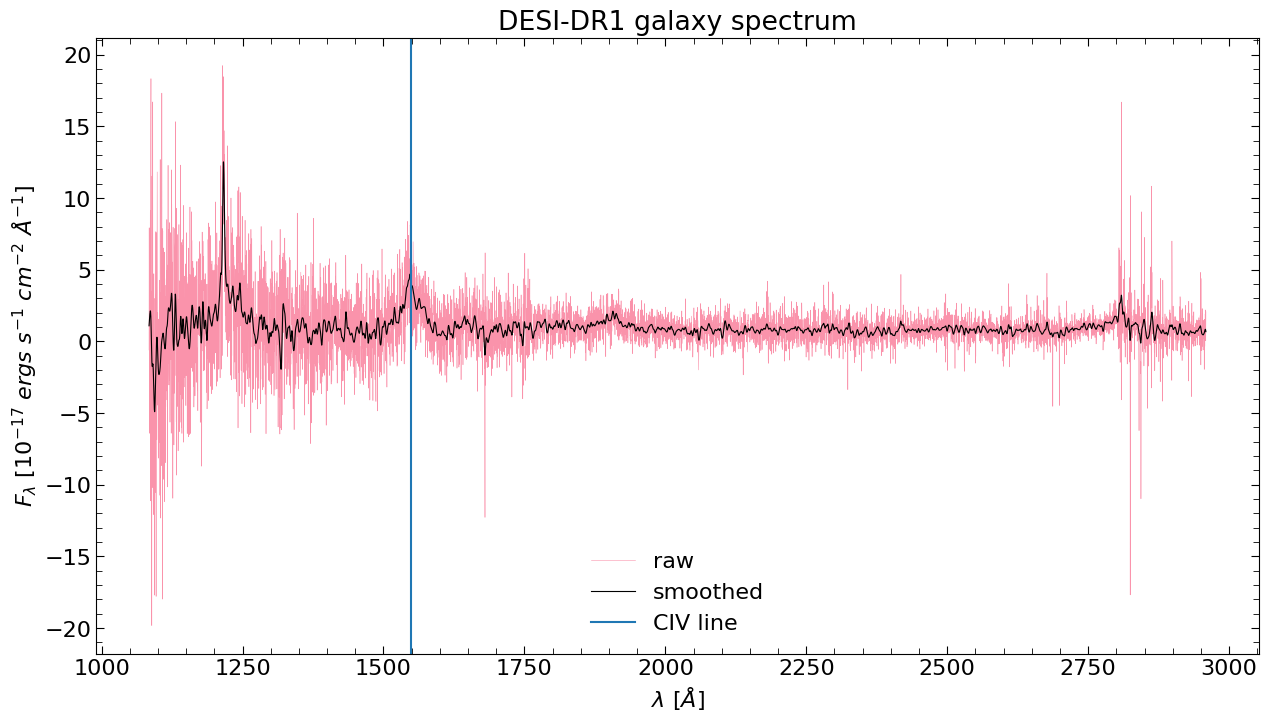

In [5]:
idx = 2


lam = np.array(spectra_df["wavelength"][idx])
flux = np.array(spectra_df["flux"][idx])
z = spectra_df["redshift"][idx]

specid = spectra_df["specid"][idx]

lam, flux = adjust_redshift(lam, flux, z)

plot_spectrum(lam, flux, line_lambda=1548, line_label="CIV line")

### lmfit

In [6]:
## cut to CIV relevant section
lower_lim, upper_lim = 1350,1750  # establish limits

lam_subset, flux_subset = [], []

# cut lists
for i in range(len(lam)):
    if lam[i] >= lower_lim and lam[i] <= upper_lim:
        lam_subset.append(lam[i])
        flux_subset.append(flux[i])

flux_subset = convolve(flux_subset, Gaussian1DKernel(5))

lam_subset = np.array(lam_subset)

assert len(lam_subset) == len(flux_subset)  # sanity check

In [7]:
gaussian1 = GaussianModel(prefix="g1_")
gaussian2 = GaussianModel(prefix="g2_")
background = LinearModel()
model = gaussian1 + gaussian2 + background

# check which params need to be specified
print('parameter names: {}'.format(model.param_names))
print('independent variables: {}'.format(model.independent_vars))

parameter names: ['g1_amplitude', 'g1_center', 'g1_sigma', 'g2_amplitude', 'g2_center', 'g2_sigma', 'slope', 'intercept']
independent variables: ['x']


In [8]:
params = model.make_params()

params['g1_center'].set(value=1549)
params['g1_amplitude'].set(value=5)
params['g1_sigma'].set(value=10)

params['g2_center'].set(value=1549)
params['g2_amplitude'].set(value=2.5)
params['g2_sigma'].set(value=30)

params["slope"].set(value=0)
params["intercept"].set(value=1)

result = model.fit(flux_subset, params, x=lam_subset)

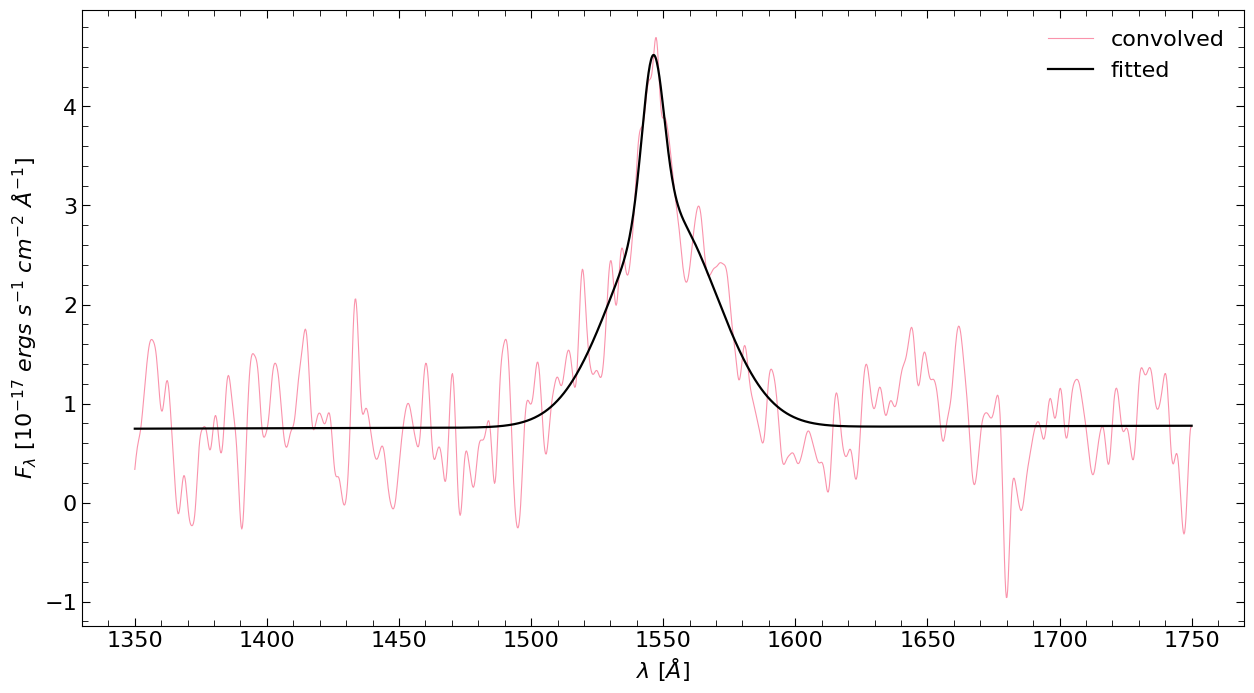

In [17]:
y_fit = result.best_fit # the simulated intensity

# comparison of fitted spectrum with original one
plot_spectrum(lam_subset, flux_subset, title="", flux_label="convolved", add_smoothed=False, additional_flux=y_fit, additional_flux_label="fitted", line_width_factor=2)        

plt.show()

In [10]:
# def linear_values(x, slope, intercept):
#     return np.array(x)*slope + intercept

# linear_y = linear_values(lam_subset,result.best_values["slope"], result.best_values["intercept"])

# linear_y

# does the same as above
components = result.eval_components(x=lam_subset)
linear_y = components["linear"]

# sum(components["linear"] != linear_y)

In [18]:
# get flux
mask = (y_fit-linear_y > 1E-5)  # use this to extract the line borders

# trapezoid(y_fit[mask],lam_subset[mask])
trapezoid(y_fit[mask]-linear_y[mask],lam_subset[mask])

125.35448083594912

In [12]:
# get flux that desi provides
desi_civ_flux = results[results["targetid"] == specid]["civ_1549_flux"]

desi_civ_flux

3    233.59863
Name: civ_1549_flux, dtype: float64

### specutils

In [13]:
flux_unit = u.erg / (u.s * u.cm**2 * u.AA)

# Spectrum1D object needs Quantity objects which have units
flux_q = convolve(flux, Gaussian1DKernel(5)) * flux_unit
lam_q = lam * u.AA

spec1d = Spectrum1D(flux=flux_q, spectral_axis=lam_q)

In [14]:
nv_region = SpectralRegion(1200*u.AA, 1250*u.AA)
civ_region = SpectralRegion(1500*u.AA, 1600*u.AA)

continuum_fit = fit_generic_continuum(spec1d, exclude_regions=[nv_region, civ_region])

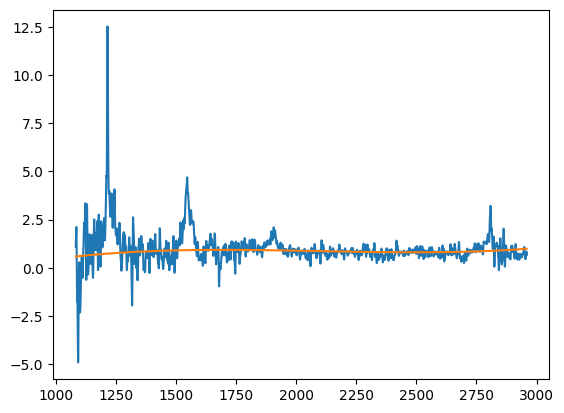

In [ ]:
y_continuum_fitted = continuum_fit(lam_q)

plt.plot(lam_q,flux_q)
plt.plot(lam_q,y_continuum_fitted)
plot_spectrum(lam_q, flux_q, title="",flux_label="convolved","")